# Marker positivity

Reproduces the **marker-positivity (MP)** decision-quality panels of the DeepCell Types paper. Marker positivity asks, per cell and per protein marker, whether that marker is expressed — a binary call the FiLM-conditioned MP head produces from the shared cell embedding, closed at a learned per-marker threshold τ.

Panels, in order:

- **Summary vs baselines** (`mp_summary_comparison`) and the **per-marker F1 waterfall** (`mp_per_marker_waterfall`) on the v10 held-out test split.
- **Gold-standard per-dataset** macro F1 and the **Ours vs Nimbus** paired / delta per-marker comparisons on the Pan-Multiplex Gold Standard (`mp_gold_per_dataset`, `mp_gold_paired_bars`, `mp_gold_delta_bars`).
- **FiLM decision curves** for CD45 / CD206 / SMA and the **learned-τ histogram** (`film_mp_decision_*`, `film_mp_threshold_histogram`).
- **Per-FOV exemplars** (`mp_fov_exemplar_*`) — Ground truth vs DCT (Ours) vs Nimbus per-cell positivity maps on single Gold-Standard FOVs.

> The FOV-exemplar panels read raw segmentation masks from the gold-standard zarr archive (`paths.GOLD_ZARR`) plus the per-cell ground truth (`paths.GOLD_GT`); those cells are slower to execute.

All figures are styled to the **Science Advances 2026** figure spec via `dct_figures.style`. DCT MP calls use the released Frozen-CLS checkpoint; Nimbus is the published baseline at τ=0.5.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd()))
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns, json
from dct_figures import paths, style, colors
style.apply_style()

## Shared inputs

All MP inputs live under `paths.OUTPUT`. The gold-standard JSONs were produced with `--model final_frozen_cls` (DCT) and the canonical Nimbus eval. The FOV-exemplar panels additionally read `paths.GOLD_GT` (per-cell ground truth) and `paths.GOLD_ZARR` (segmentation masks).

In [2]:
from dct_figures.style import (PAL, COL_2, COL_1_5, COL_1, BAR_WIDTH,
    BAR_WIDTH_GROUP, FS_AXIS_TITLE, FS_AXIS_LABEL, FS_BODY, FS_TICK,
    FS_SMALL, FS_TINY, PERF_BAR_INCHES, PERF_BAR_PITCH_INCHES,
    setup_perf_bar_axes)
import matplotlib.ticker as mticker
from matplotlib.patches import Patch

# Production operating point: --model final_frozen_cls, --data_dir output.
MP_PER_MARKER = paths.OUTPUT / 'final_frozen_cls_mp_per_marker.csv'
OURS_GOLD     = paths.OUTPUT / 'final_frozen_cls_gold_metrics.json'
NIMBUS_GOLD   = paths.OUTPUT / 'nimbus_gold_metrics.json'
OURS_ALL      = paths.OUTPUT / 'final_frozen_cls_mp_all_datasets.json'
NIMBUS_ALL    = paths.OUTPUT / 'nimbus_all_mp_nimbus_metrics.json'
TEST_MP_PREDS = paths.OUTPUT / 'final_frozen_cls_test_mp_preds.csv'
THRESHOLDS    = paths.OUTPUT / 'final_frozen_cls_mp_thresholds.json'
GOLD_PREDS    = paths.OUTPUT / 'final_frozen_cls_gold_preds.csv'
NIMBUS_PREDS  = paths.OUTPUT / 'nimbus_gold_preds.csv'
for p in (MP_PER_MARKER, OURS_GOLD, NIMBUS_GOLD, OURS_ALL, NIMBUS_ALL,
          TEST_MP_PREDS, THRESHOLDS, GOLD_PREDS, NIMBUS_PREDS):
    paths.need(p)
print('all MP inputs present')

all MP inputs present


## mp_summary_comparison

_Caption:_ Headline marker-positivity macro/weighted metrics across methods. Macro F1 for DCT (Ours) vs Nimbus in two settings: the Pan-M Gold Standard and the all-datasets v10 evaluation.

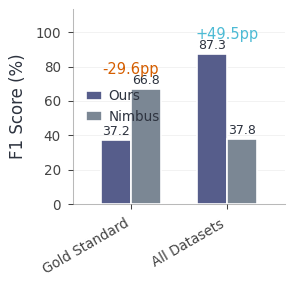

In [3]:
ours_gold = json.load(open(OURS_GOLD))
nimbus_gold = json.load(open(NIMBUS_GOLD))
ours_all = json.load(open(OURS_ALL))
nimbus_all = json.load(open(NIMBUS_ALL))

settings = ['Gold Standard', 'All Datasets']
ours_vals = [ours_gold['macro_f1'] * 100,
             ours_all['metrics']['mp_macro_f1'] * 100]
nimbus_all_pm = nimbus_all['per_marker']
nimbus_all_macro = float(np.mean([v['f1'] for v in nimbus_all_pm.values()]) * 100)
nimbus_vals = [nimbus_gold['macro_f1'] * 100, nimbus_all_macro]

fig, ax = plt.subplots(figsize=(COL_1_5, 3.0))
x, w = setup_perf_bar_axes(fig, ax, len(settings),
                           target_bar_inches=PERF_BAR_INCHES,
                           target_pitch_inches=2 * PERF_BAR_PITCH_INCHES)
b1 = ax.bar(x - w / 2, ours_vals, w, color=PAL['theme'], label='Ours',
            edgecolor='white', linewidth=0.8, zorder=3)
b2 = ax.bar(x + w / 2, nimbus_vals, w, color=PAL['gray'], label='Nimbus',
            edgecolor='white', linewidth=0.8, zorder=3)
ax.set_ylabel('F1 Score (%)')
ax.set_xticks(x)
ax.set_xticklabels(settings, fontsize=FS_TICK, rotation=30, ha='right')
top = max(max(ours_vals), max(nimbus_vals))
ax.set_ylim(0, top * 1.30)
ax.legend(fontsize=FS_TICK, loc='center left', frameon=False,
          handlelength=1.2, columnspacing=1.2)
style.style_ax(ax)
style.add_value_labels(ax, b1, fmt='{:.1f}', fontsize=FS_SMALL, offset=1)
style.add_value_labels(ax, b2, fmt='{:.1f}', fontsize=FS_SMALL, offset=1)
for i in range(len(settings)):
    diff = ours_vals[i] - nimbus_vals[i]
    ax.text(x[i], max(ours_vals[i], nimbus_vals[i]) + 7,
            f'+{diff:.1f}pp' if diff > 0 else f'{diff:.1f}pp',
            ha='center', va='bottom', fontsize=FS_BODY,
            color=PAL['teal'] if diff > 0 else PAL['red'])
plt.show()

## mp_per_marker_waterfall

_Caption:_ Per-marker F1 waterfall for Frozen-CLS on the v10 held-out test split (markers with F1=0 omitted). Bars sorted by F1 descending and color-tiered (≥90 / 80–89 / 60–79 / 40–59 / <40 %); the corner chip reports the macro F1 over the plotted markers.

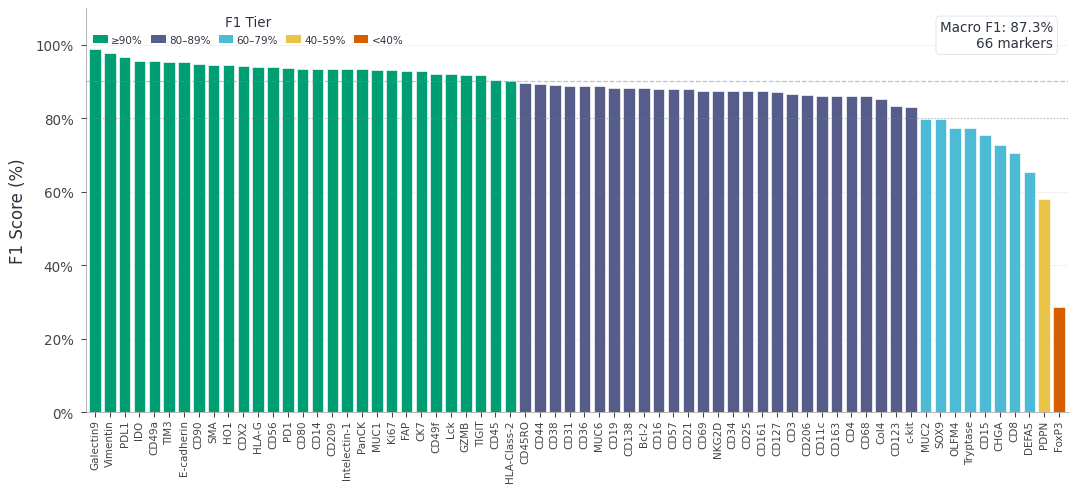

In [4]:
df = pd.read_csv(MP_PER_MARKER)
df = df[df['f1'] > 0].sort_values('f1', ascending=False).reset_index(drop=True)
n = len(df)
fig, ax = plt.subplots(figsize=(COL_2, 3.4))
wcolors = []
for f1 in df['f1']:
    if f1 >= 0.9: wcolors.append(PAL['green'])
    elif f1 >= 0.8: wcolors.append(PAL['blue'])
    elif f1 >= 0.6: wcolors.append(PAL['teal'])
    elif f1 >= 0.4: wcolors.append(PAL['yellow'])
    else: wcolors.append(PAL['red'])
ax.bar(range(n), df['f1'] * 100, color=wcolors, width=BAR_WIDTH,
       edgecolor='white', linewidth=0.3)
ax.set_xticks(range(n))
ax.set_xticklabels(df['marker'], rotation=90, ha='center', fontsize=FS_TINY)
ax.tick_params(axis='x', pad=1)
ax.set_xlim(-0.6, n - 0.4)
ax.set_ylabel('F1 Score (%)')
ax.set_ylim(0, 110)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
style.style_ax(ax)
for y, ls in [(90, '--'), (80, ':')]:
    ax.axhline(y, color=PAL['gray'], linestyle=ls, linewidth=0.6, alpha=0.5)
legend_items = [Patch(facecolor=PAL['green'], label='\u226590%'),
                Patch(facecolor=PAL['blue'], label='80\u201389%'),
                Patch(facecolor=PAL['teal'], label='60\u201379%'),
                Patch(facecolor=PAL['yellow'], label='40\u201359%'),
                Patch(facecolor=PAL['red'], label='<40%')]
ax.legend(handles=legend_items, loc='upper left', title='F1 Tier',
          fontsize=FS_TINY, title_fontsize=FS_TICK, ncol=5,
          handletextpad=0.3, columnspacing=0.8, borderaxespad=0.3)
macro_f1 = df['f1'].mean() * 100
ax.text(0.985, 0.97, f'Macro F1: {macro_f1:.1f}%\n{n} markers',
        transform=ax.transAxes, ha='right', va='top', fontsize=FS_TICK,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                  edgecolor=PAL['light_gray'], alpha=0.9))
fig.tight_layout()
plt.show()

## mp_gold_per_dataset

_Caption:_ Per-dataset marker-positivity macro F1 on the Pan-M Gold standard (Ours vs Nimbus, grouped bars).

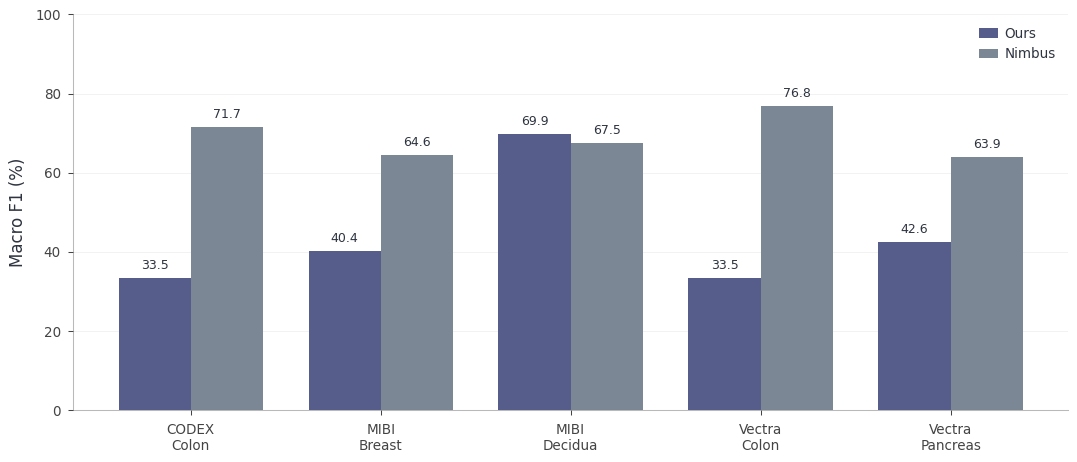

In [5]:
ours_ds = ours_gold.get('per_dataset', {})
nimbus_ds = nimbus_gold.get('per_dataset', {})
datasets = sorted(set(ours_ds) & set(nimbus_ds))
pretty = {'codex_colon': 'CODEX\nColon', 'mibi_breast': 'MIBI\nBreast',
          'mibi_decidua': 'MIBI\nDecidua', 'vectra_colon': 'Vectra\nColon',
          'vectra_pancreas': 'Vectra\nPancreas'}
labels = [pretty.get(d, d) for d in datasets]
ours_macro = [ours_ds[d]['macro_f1'] * 100 for d in datasets]
nimbus_macro = [nimbus_ds[d]['macro_f1'] * 100 for d in datasets]
x = np.arange(len(datasets)); w = BAR_WIDTH_GROUP
fig, ax1 = plt.subplots(figsize=(COL_2, 3.2))
b1 = ax1.bar(x - w / 2, ours_macro, w, color=PAL['blue'], label='Ours')
b2 = ax1.bar(x + w / 2, nimbus_macro, w, color=PAL['gray'], label='Nimbus')
ax1.set_ylabel('Macro F1 (%)')
ax1.set_xticks(x); ax1.set_xticklabels(labels, fontsize=FS_TICK)
ax1.legend(fontsize=FS_TICK); ax1.set_ylim(0, 100)
style.add_value_labels(ax1, b1); style.add_value_labels(ax1, b2)
style.style_ax(ax1)
fig.tight_layout()
plt.show()

## mp_gold_paired_bars & mp_gold_delta_bars

_Captions:_ (paired) Per-marker macro F1 on the Pan-M Gold standard, Ours vs Nimbus. (delta) Per-marker macro F1 advantage on the Gold standard paired with the v10 test split, aligned by canonical marker name.

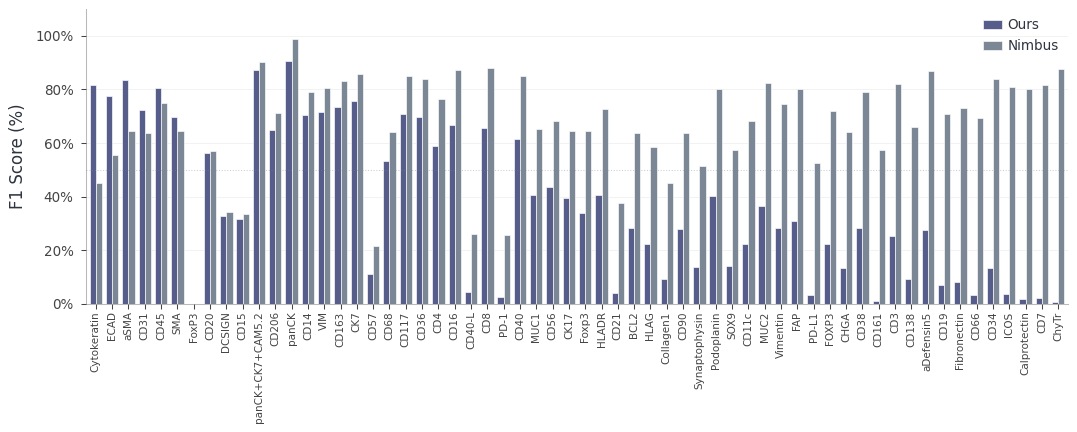

In [6]:
ours_pm = ours_gold['per_marker']; nimbus_pm = nimbus_gold['per_marker']
markers = sorted(set(ours_pm) & set(nimbus_pm))
ours_f1 = [ours_pm[m]['f1'] * 100 for m in markers]
nimbus_f1 = [nimbus_pm[m]['f1'] * 100 for m in markers]
delta = [o - nn for o, nn in zip(ours_f1, nimbus_f1)]
idx = np.argsort(delta)[::-1]
markers = [markers[i] for i in idx]
ours_f1 = [ours_f1[i] for i in idx]
nimbus_f1 = [nimbus_f1[i] for i in idx]
delta = [delta[i] for i in idx]
n = len(markers); x = np.arange(n)

# --- paired bars ---
fig, ax1 = plt.subplots(figsize=(COL_2, 3.0))
w = BAR_WIDTH_GROUP
ax1.bar(x - w / 2, ours_f1, w, color=PAL['blue'], label='Ours',
        edgecolor='white', linewidth=0.3)
ax1.bar(x + w / 2, nimbus_f1, w, color=PAL['gray'], label='Nimbus',
        edgecolor='white', linewidth=0.3)
ax1.set_ylabel('F1 Score (%)'); ax1.set_ylim(0, 110)
ax1.yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
ax1.legend(fontsize=FS_TICK, loc='upper right', handletextpad=0.4,
           borderaxespad=0.3)
ax1.axhline(50, color=PAL['gray'], linestyle=':', linewidth=0.5, alpha=0.4)
ax1.set_xticks(x)
ax1.set_xticklabels(markers, rotation=90, ha='center', fontsize=FS_TINY)
ax1.tick_params(axis='x', pad=1); ax1.set_xlim(-0.6, n - 0.4)
style.style_ax(ax1)
fig.tight_layout()
plt.show()

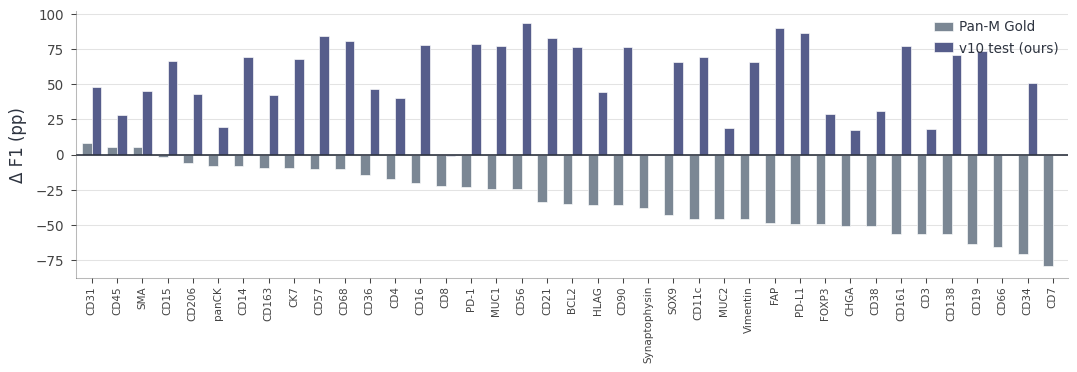

In [7]:
# --- delta bars: Gold vs v10 test, aligned by canonical marker ---
def _canon(m):
    return m.upper().replace('-', '').replace(' ', '')
gold_canon = {_canon(m): d for m, d in zip(markers, delta)}

v10_ours_csv = paths.OUTPUT / 'final_frozen_cls_mp_per_marker.csv'
v10_nim_json = paths.OUTPUT / 'nimbus_v10_0_nimbus_metrics.json'
have_v10 = v10_ours_csv.exists() and v10_nim_json.exists()
v10_canon = {}
if have_v10:
    v10_o = pd.read_csv(v10_ours_csv).set_index('marker')['f1'].to_dict()
    v10_n_pm = json.load(open(v10_nim_json))['per_marker']
    v10_n = {m: v['f1'] for m, v in v10_n_pm.items()}
    for m, o in v10_o.items():
        nm = v10_n.get(m)
        if nm is not None:
            v10_canon[_canon(m)] = (o - nm) * 100.0

fig, ax2 = plt.subplots(figsize=(COL_2, 2.6))
if have_v10:
    shared = [c for c in gold_canon if c in v10_canon]
    shared.sort(key=lambda c: -gold_canon[c])
    canon_to_pretty = {_canon(m): m for m in markers}
    labels = [canon_to_pretty[c] for c in shared]
    gold_vals = [gold_canon[c] for c in shared]
    v10_vals = [v10_canon[c] for c in shared]
    ns = len(shared); x2 = np.arange(ns); w = BAR_WIDTH_GROUP
    ax2.bar(x2 - w / 2, gold_vals, w, color=PAL['gray'], label='Pan-M Gold',
            edgecolor='white', linewidth=0.3)
    ax2.bar(x2 + w / 2, v10_vals, w, color=PAL['theme'], label='v10 test (ours)',
            edgecolor='white', linewidth=0.3)
    ax2.set_xticks(x2)
    ax2.set_xticklabels(labels, rotation=90, ha='center', fontsize=FS_TINY)
    ax2.set_xlim(-0.6, ns - 0.4)
else:
    cols = [PAL['teal'] if d > 0 else PAL['red'] for d in delta]
    ax2.bar(x, delta, BAR_WIDTH, color=cols, edgecolor='white', linewidth=0.3)
    ax2.set_xticks(x)
    ax2.set_xticklabels(markers, rotation=90, ha='center', fontsize=FS_TINY)
    ax2.set_xlim(-0.6, n - 0.4)
ax2.axhline(0, color=PAL['dark'], linewidth=0.8)
ax2.set_ylabel('\u0394 F1 (pp)')
ax2.tick_params(axis='x', pad=1)
ax2.legend(fontsize=FS_TICK, loc='upper right', handletextpad=0.4,
           borderaxespad=0.3)
style.style_ax(ax2)
ax2.yaxis.grid(True, alpha=0.35, linewidth=0.5, zorder=0)
ax2.set_axisbelow(True)
fig.tight_layout()
plt.show()

## FiLM MP decision curves

For CD45 (pan-immune), CD206 (macrophage subset) and SMA (smooth muscle): the predicted MP-probability distribution for GT positives vs negatives on the v10 test split, with the learned threshold τ marked. The spread of τ away from 0.5 is direct evidence the FiLM head produces marker-specific decision functions.

In [8]:
MARKERS = [('CD45', 'Pan immune'), ('CD206', 'Macrophage subset'),
           ('SMA', 'Smooth muscle')]
th = json.load(open(THRESHOLDS))
td = pd.read_csv(TEST_MP_PREDS)

def _load_marker_test(marker):
    j = td[td.channel == marker][['fov', 'cell_id', 'activity', 'pred_score']].copy()
    return j[j.activity.isin([0, 1])].reset_index(drop=True)

def _decision_panel(marker, subtitle):
    j = _load_marker_test(marker)
    tau = float(th.get(marker, 0.5))
    pos = j.loc[j.activity == 1, 'pred_score'].to_numpy()
    neg = j.loc[j.activity == 0, 'pred_score'].to_numpy()
    bins = np.linspace(0.0, 1.0, 41)
    fig, ax = plt.subplots(figsize=(COL_1, 2.6))
    ax.hist(neg, bins=bins, color=PAL['theme_light'], alpha=0.85,
            edgecolor='white', linewidth=0.3,
            label=f'GT negative (n={len(neg):,})', zorder=2)
    ax.hist(pos, bins=bins, color=PAL['red'], alpha=0.75,
            edgecolor='white', linewidth=0.3,
            label=f'GT positive (n={len(pos):,})', zorder=3)
    ax.axvline(tau, color=PAL['dark'], linestyle='--', linewidth=1.0, zorder=4)
    ax.text(tau, 0.55, f' \u03c4 = {tau:.2f}', ha='left', va='center',
            fontsize=7.0, color=PAL['dark'],
            transform=ax.get_xaxis_transform(),
            bbox=dict(boxstyle='round,pad=0.18', facecolor='white',
                      edgecolor=PAL['light_gray'], linewidth=0.4, alpha=0.92))
    ax.set_xlim(0, 1); ax.set_yscale('log')
    ax.set_xlabel('Predicted MP probability'); ax.set_ylabel('Cells (log)')
    ax.set_title(f'{marker} \u2014 {subtitle}', fontsize=FS_BODY)
    ax.legend(loc='upper center', fontsize=6.8, framealpha=0.92,
              handletextpad=0.5, borderaxespad=0.4)
    style.style_ax(ax, grid_axis='y')
    fig.tight_layout()
    plt.show()
    print(f'  {marker}: {len(j):,} cells (pos {(j.activity==1).sum():,}, '
          f'neg {(j.activity==0).sum():,}), \u03c4={tau:.2f}')

panel_taus = {m: float(th.get(m, 0.5)) for m, _ in MARKERS}

### film_mp_decision_cd45

_Caption:_ FiLM MP decision curve — CD45 (pan-immune).

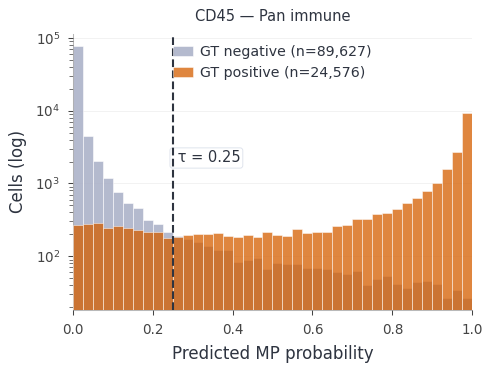

  CD45: 114,203 cells (pos 24,576, neg 89,627), τ=0.25


In [9]:
_decision_panel('CD45', 'Pan immune')

### film_mp_decision_cd206

_Caption:_ FiLM MP decision curve — CD206 (macrophage subset).

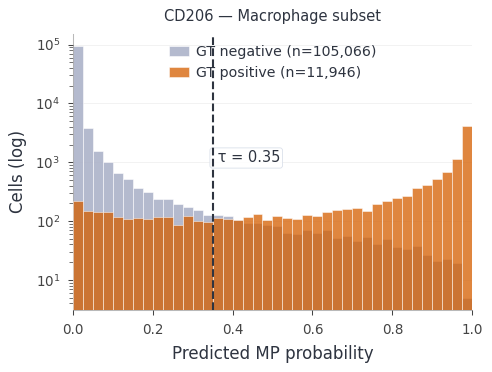

  CD206: 117,012 cells (pos 11,946, neg 105,066), τ=0.35


In [10]:
_decision_panel('CD206', 'Macrophage subset')

### film_mp_decision_sma

_Caption:_ FiLM MP decision curve — SMA (smooth muscle).

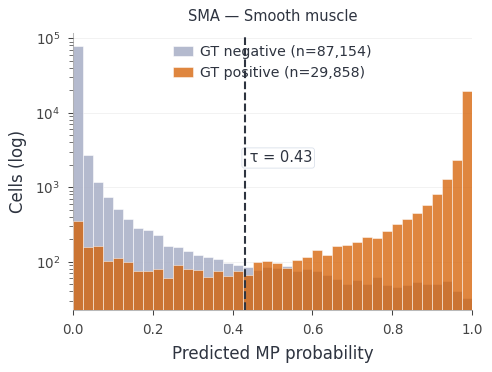

  SMA: 117,012 cells (pos 29,858, neg 87,154), τ=0.43


In [11]:
_decision_panel('SMA', 'Smooth muscle')

## film_mp_threshold_histogram

_Caption:_ Histogram of learned per-marker thresholds τ swept on the train split. The three decision-curve markers are tagged; the spread around the default 0.5 quantifies the marker-specific operating points.

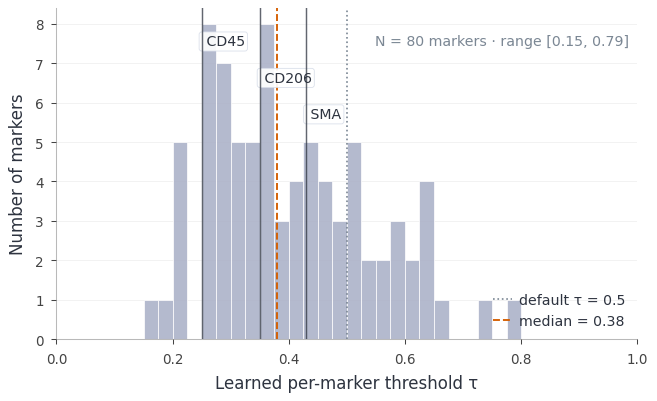

In [12]:
vals = np.array(list(th.values()), dtype=float)
bins = np.arange(0.0, 1.005, 0.025)
fig, ax = plt.subplots(figsize=(COL_1_5, 2.8))
ax.hist(vals, bins=bins, color=PAL['theme_light'], edgecolor='white',
        linewidth=0.4, alpha=0.85, zorder=2)
ax.axvline(0.5, color=PAL['gray'], linestyle=':', linewidth=0.8,
           label='default \u03c4 = 0.5', zorder=3)
median = float(np.median(vals))
ax.axvline(median, color=PAL['red'], linestyle='--', linewidth=0.9,
           label=f'median = {median:.2f}', zorder=3)
for i, (marker, tau) in enumerate(sorted(panel_taus.items(), key=lambda kv: kv[1])):
    ax.axvline(tau, color=PAL['dark'], linewidth=0.7, alpha=0.75, zorder=4)
    ax.text(tau, 0.92 - 0.11 * i, f' {marker}', ha='left', va='top',
            fontsize=6.8, color=PAL['dark'],
            transform=ax.get_xaxis_transform(),
            bbox=dict(boxstyle='round,pad=0.18', facecolor='white',
                      edgecolor=PAL['light_gray'], linewidth=0.4, alpha=0.92))
ax.text(0.985, 0.92,
        f'N = {len(vals)} markers \u00b7 range '
        f'[{vals.min():.2f}, {vals.max():.2f}]',
        transform=ax.transAxes, ha='right', va='top', fontsize=6.8,
        color=PAL['gray'])
ax.set_xlim(0, 1)
ax.set_xlabel('Learned per-marker threshold \u03c4')
ax.set_ylabel('Number of markers')
ax.legend(loc='lower right', fontsize=6.8, framealpha=0.92,
          handletextpad=0.5, borderaxespad=0.4)
style.style_ax(ax, grid_axis='y')
fig.tight_layout()
plt.show()

## Per-FOV marker-positivity exemplars

Each exemplar renders three side-by-side panels — **Ground truth**, **DCT (Ours)**, **Nimbus** — on a single Pan-M Gold-Standard FOV, coloring every cell by binary positivity for one marker (positive = vermillion, negative = light gray, no cell = white). The per-panel chip reports per-FOV macro F1 (Ours at the learned τ, Nimbus at τ=0.5). Segmentation masks are read from the gold zarr (`paths.GOLD_ZARR`); per-cell ground truth from `paths.GOLD_GT`.

In [13]:
import zarr
from sklearn.metrics import f1_score

POS_COLOR = PAL['red']; NEG_COLOR = PAL['light_gray']; BG_COLOR = '#FFFFFF'
NIMBUS_THRESHOLD = 0.5

_gt_all = pd.read_csv(paths.need(paths.GOLD_GT))
_ours_all = pd.read_csv(GOLD_PREDS)
_nim_all = pd.read_csv(NIMBUS_PREDS)
_zroot = zarr.open_group(str(paths.GOLD_ZARR), mode='r')
_th = json.load(open(THRESHOLDS))

def _fov_zarr_key(fov):
    cands = [k for k in _zroot.group_keys() if k.endswith(f'__{fov}') or k == fov]
    if not cands:
        raise KeyError(f'FOV {fov!r} not in zarr')
    return cands[0]

def _crop_around_cells(mask, cells, crop_side):
    H, W = mask.shape
    if crop_side is None or crop_side <= 0 or crop_side >= min(H, W):
        return 0, 0, H, W
    sel = np.isin(mask, cells) if cells.size else (mask > 0)
    if not sel.any():
        return 0, 0, H, W
    rows = np.where(sel.any(axis=1))[0]; cols = np.where(sel.any(axis=0))[0]
    cr = int((rows.min() + rows.max()) // 2); cc = int((cols.min() + cols.max()) // 2)
    half = crop_side // 2
    r0 = max(0, min(cr - half, H - crop_side)); c0 = max(0, min(cc - half, W - crop_side))
    return r0, c0, crop_side, crop_side

def _render_panel(ax, sub_mask, label_map):
    H, W = sub_mask.shape
    rgb = np.ones((H, W, 4), dtype=np.float32)
    rgb[..., :3] = np.array(plt.matplotlib.colors.to_rgb(BG_COLOR))
    pos_ids = np.asarray([c for c, v in label_map.items() if v == 1], dtype=np.int64)
    neg_ids = np.asarray([c for c, v in label_map.items() if v == 0], dtype=np.int64)
    if neg_ids.size:
        rgb[np.isin(sub_mask, neg_ids)] = plt.matplotlib.colors.to_rgba(NEG_COLOR)
    if pos_ids.size:
        rgb[np.isin(sub_mask, pos_ids)] = plt.matplotlib.colors.to_rgba(POS_COLOR)
    if (sub_mask > 0).any():
        rd = np.zeros_like(sub_mask, dtype=bool); dd = np.zeros_like(sub_mask, dtype=bool)
        rd[:, :-1] = (sub_mask[:, :-1] != sub_mask[:, 1:]) & (sub_mask[:, :-1] > 0) & (sub_mask[:, 1:] > 0)
        dd[:-1, :] = (sub_mask[:-1, :] != sub_mask[1:, :]) & (sub_mask[:-1, :] > 0) & (sub_mask[1:, :] > 0)
        rgb[rd | dd] = (1.0, 1.0, 1.0, 1.0)
    ax.imshow(rgb, interpolation='nearest', aspect='equal')
    ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values():
        sp.set_alpha(0.35)

def _add_scale_bar(ax, mpp, bar_um=100.0, color='#2E3440'):
    H = ax.get_ylim()[0]; W = ax.get_xlim()[1]; bar_px = bar_um / mpp
    pad = max(W, H) * 0.025; y_bar = H - pad - 4; x_right = W - pad
    ax.plot([x_right - bar_px, x_right], [y_bar, y_bar], color=color, lw=2.0,
            solid_capstyle='butt')
    ax.text(x_right - bar_px / 2.0, y_bar - 6, f'{bar_um:g} \u03bcm', ha='center',
            va='bottom', fontsize=FS_SMALL, color=color)

def fov_exemplar(fov, marker, crop_side=1100):
    gt = _gt_all[(_gt_all['fov'] == fov) & (_gt_all['channel'] == marker)
                 & (_gt_all['activity'].isin([0, 1]))][['cell_id', 'activity']]
    ours = _ours_all[(_ours_all['fov'] == fov) & (_ours_all['channel'] == marker)][['cell_id', 'pred_score']]
    nim = _nim_all[(_nim_all['fov'] == fov) & (_nim_all['channel'] == marker)][['cell_id', 'pred_score']]
    merged = gt.merge(ours, on='cell_id').merge(nim, on='cell_id', suffixes=('_ours', '_nimbus'))
    th_ours = float(_th.get(marker, 0.5))
    y_true = merged['activity'].to_numpy()
    f1_ours = float(f1_score(y_true, (merged['pred_score_ours'] >= th_ours).astype(int), average='macro', zero_division=0))
    f1_nim = float(f1_score(y_true, (merged['pred_score_nimbus'] >= NIMBUS_THRESHOLD).astype(int), average='macro', zero_division=0))
    n_pos = int(merged['activity'].sum()); n_tot = int(len(merged))
    grp = _zroot[_fov_zarr_key(fov)]
    mask = grp['preprocessed/mask'][:]
    mpp = float(grp['preprocessed'].attrs.get('mpp', 0.5))
    gt_lm = {int(c): int(p) for c, p in merged[['cell_id', 'activity']].itertuples(index=False)}
    ours_lm = {int(c): int(p) for c, p in merged.assign(p=(merged['pred_score_ours'] >= th_ours).astype(int))[['cell_id', 'p']].itertuples(index=False)}
    nim_lm = {int(c): int(p) for c, p in merged.assign(p=(merged['pred_score_nimbus'] >= NIMBUS_THRESHOLD).astype(int))[['cell_id', 'p']].itertuples(index=False)}
    evaluated = merged['cell_id'].to_numpy(dtype=np.int64)
    r0, c0, sh, sw = _crop_around_cells(mask, evaluated, crop_side)
    sub_mask = mask[r0:r0 + sh, c0:c0 + sw]
    fig_h = COL_2 / 3.0 + 0.55
    fig, axes = plt.subplots(1, 3, figsize=(COL_2, fig_h),
        gridspec_kw=dict(wspace=0.04, left=0.005, right=0.995, top=0.83, bottom=0.05))
    panels = [('Ground truth', gt_lm, None), ('DCT (Ours)', ours_lm, f1_ours),
              ('Nimbus', nim_lm, f1_nim)]
    for ax, (title, lmap, f1) in zip(axes, panels):
        _render_panel(ax, sub_mask, lmap)
        ax.set_title(title, fontsize=FS_AXIS_LABEL, pad=4)
        _add_scale_bar(ax, mpp)
        chip = f'n = {n_tot}   pos = {n_pos}' if f1 is None else f'macro F1 = {f1:.2f}'
        ax.text(0.02, 0.02, chip, transform=ax.transAxes, ha='left', va='bottom',
                fontsize=FS_BODY, color='white',
                bbox=dict(boxstyle='round,pad=0.25', facecolor='#2E3440', alpha=0.7, edgecolor='none'),
                zorder=5)
    leg = fig.add_axes([0.71, 0.91, 0.28, 0.06]); leg.set_xlim(0, 1); leg.set_ylim(0, 1); leg.axis('off')
    leg.add_patch(plt.Rectangle((0.0, 0.2), 0.08, 0.6, facecolor=POS_COLOR, edgecolor='none'))
    leg.text(0.10, 0.5, 'positive', va='center', ha='left', fontsize=FS_TICK, color=PAL['dark'])
    leg.add_patch(plt.Rectangle((0.46, 0.2), 0.08, 0.6, facecolor=NEG_COLOR, edgecolor='#9AA3B0'))
    leg.text(0.56, 0.5, 'negative', va='center', ha='left', fontsize=FS_TICK, color=PAL['dark'])
    plt.show()
    print(f'FOV={fov} marker={marker}: merged={n_tot} pos={n_pos} '
          f'Ours F1={f1_ours:.3f} (\u03c4={th_ours:.2f}) Nimbus F1={f1_nim:.3f}')

### mp_fov_exemplar_cd3_mibi_breast

_Caption:_ MP exemplar — CD3 (pan-Tcell) on mibi_breast FOV TONIC_TMA10_R5C4: Ours vs Nimbus per-cell positivity.

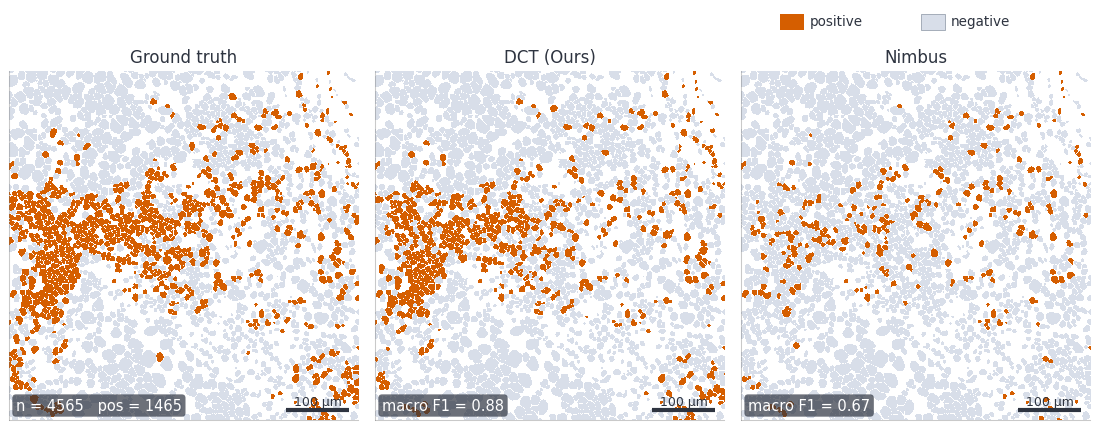

FOV=TONIC_TMA10_R5C4 marker=CD3: merged=4565 pos=1465 Ours F1=0.880 (τ=0.31) Nimbus F1=0.675


In [14]:
fov_exemplar('TONIC_TMA10_R5C4', 'CD3', crop_side=1100)

### mp_fov_exemplar_sma_mibi_decidua

_Caption:_ MP exemplar — SMA (smooth muscle) on mibi_decidua FOV 12_31750_1_10.

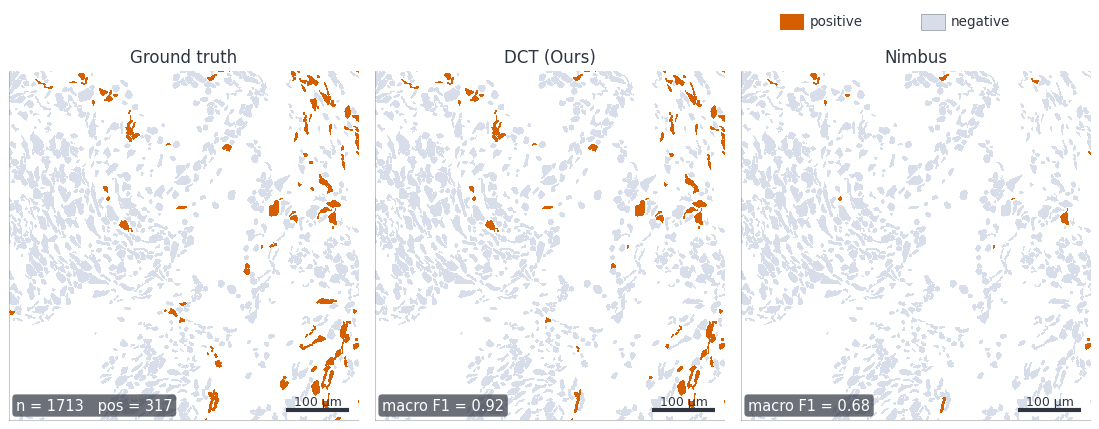

FOV=12_31750_1_10 marker=SMA: merged=1713 pos=317 Ours F1=0.924 (τ=0.43) Nimbus F1=0.679


In [15]:
fov_exemplar('12_31750_1_10', 'SMA', crop_side=1100)

### mp_fov_exemplar_pdl1_vectra_colon

_Caption:_ MP exemplar — PD-L1 on vectra_colon (a Nimbus-specialized marker): shows where Nimbus wins.

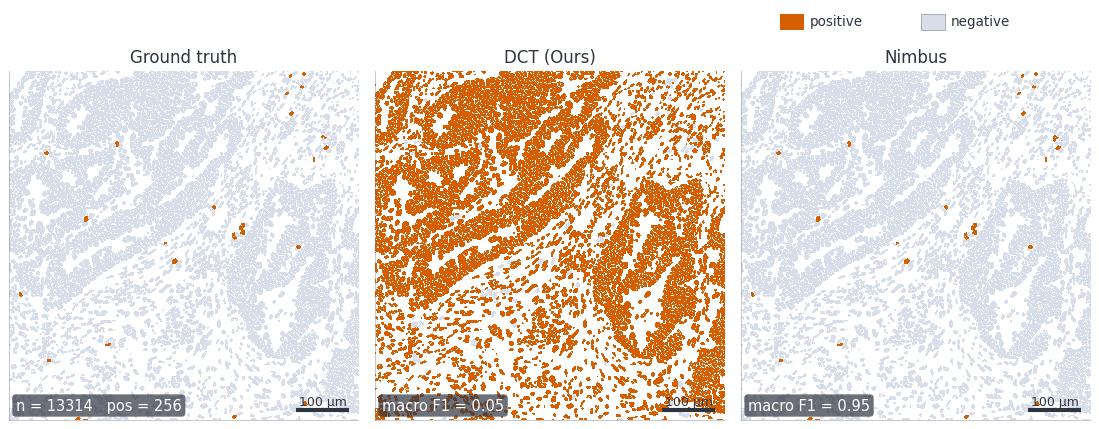

FOV=9c68495d8667_Colon P20 CD3, Foxp1, PDL1, ICOS, CD8, panCK+CK7+CAM5.2__[55647,17034]_image marker=PD-L1: merged=13314 pos=256 Ours F1=0.045 (τ=0.50) Nimbus F1=0.950


In [16]:
fov_exemplar('9c68495d8667_Colon P20 CD3, Foxp1, PDL1, ICOS, CD8, panCK+CK7+CAM5.2__[55647,17034]_image', 'PD-L1', crop_side=1300)